In [25]:
import scipy
# Read the CSV files
df_blue = pd.read_csv('pass_gen_comparison_blue.csv', header=None)
df_yellow = pd.read_csv('pass_gen_comparison_yellow.csv', header=None)

# Concatenate the dataframes
df_combined = pd.concat([df_blue, df_yellow], axis=0)
df_combined = df_combined.dropna()

scipy.stats.mode(df_combined)

/tmp/ipykernel_18194/1781687529.py:10: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  scipy.stats.mode(df_combined)


ModeResult(mode=array([[0.      , 0.      , 0.756115]]), count=array([[115, 107, 379]]))

             0         1         2         0         1         2
0     0.025034  0.025690  0.024884  0.005921  0.017713  0.002037
1     0.030920  0.027510  0.024884  0.025148  0.025997  0.007425
2     0.032423  0.035059  0.028501  0.031758  0.031322  0.031885
3     0.037923  0.033888  0.028501  0.034376  0.032794  0.031885
4     0.040458  0.020872  0.028501  0.033150  0.025396  0.031885
...        ...       ...       ...       ...       ...       ...
1772  0.012172  0.214818  0.210500  0.670980  0.649146  0.662933
1773  0.017412  0.688508  0.210500  0.685004  0.642725  0.662933
1774  0.029226  0.926433  0.150336  0.699635  0.629081  0.695970
1775  0.979556  0.980147  0.150336  0.714163  0.688475  0.695970
1776  0.426924  0.353613  0.150336  0.826335  0.778185  0.695970

[1777 rows x 6 columns]


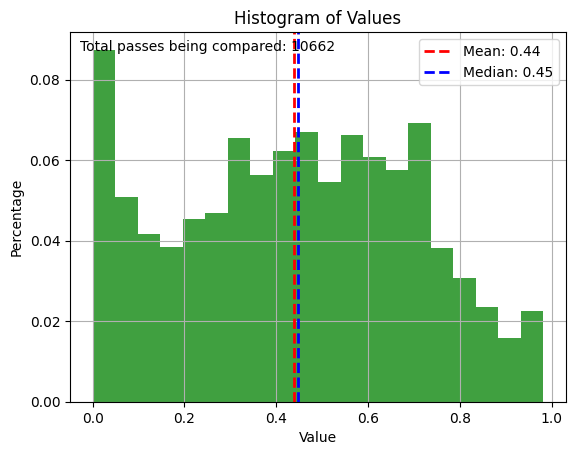

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV files
df_blue = pd.read_csv('pass_gen_comparison_blue.csv', header=None)
df_yellow = pd.read_csv('pass_gen_comparison_yellow.csv', header=None)

# Concatenate the dataframes
df_combined = pd.concat([df_blue, df_yellow], axis=1)
df_combined = df_combined.dropna()

# Calculate weights for each value to represent percentages
weights = np.ones_like(df_combined.values.flatten()) / len(df_combined.values.flatten())

# Calculate mean and median
mean_val = np.mean(df_combined.values.flatten())
median_val = np.median(df_combined.values.flatten())

# Calculate total number of data points
total_data_points = len(df_combined.values.flatten())

# Plot a histogram
plt.hist(df_combined.values.flatten(), bins=20, color='g', alpha=0.75, weights=weights)

# Draw lines for mean and median
plt.axvline(mean_val, color='r', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='b', linestyle='dashed', linewidth=2, label=f'Median: {median_val:.2f}')

# Add text for total number of data points
plt.text(0.02, 0.95, f'Total passes being compared: {total_data_points}', transform=plt.gca().transAxes)

plt.xlabel('Value')
plt.ylabel('Percentage')
plt.title('Histogram of Values')
plt.legend()
plt.grid(True)
plt.show()

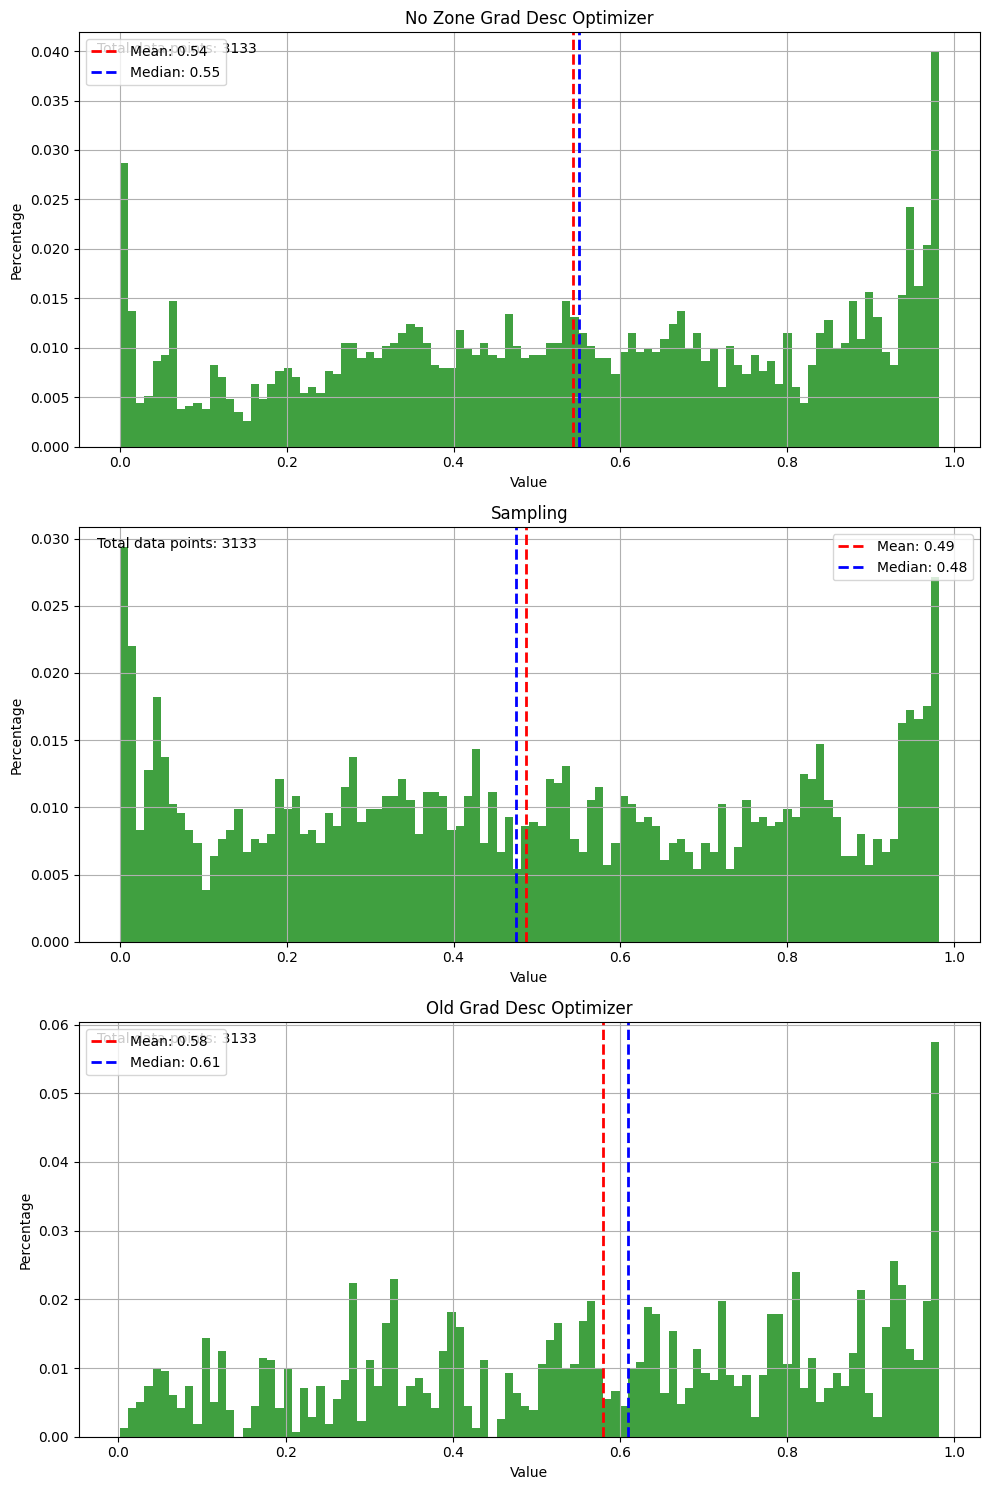

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV files
df_blue = pd.read_csv('pass_gen_comparison_blue.csv', header=None)
df_yellow = pd.read_csv('pass_gen_comparison_yellow.csv', header=None)

# Concatenate the dataframes
df_combined = pd.concat([df_blue, df_yellow], axis=0)
df_combined = df_combined.dropna()

# Create a figure with three subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

titles = ["No Zone Grad Desc Optimizer", "Sampling", "Old Grad Desc Optimizer"]

# Plot a histogram for each column
for i in range(3):
    # Calculate weights for each value to represent percentages
    weights = np.ones_like(df_combined[i].values) / len(df_combined[i].values)

    # Calculate mean and median
    mean_val = np.mean(df_combined[i].values)
    median_val = np.median(df_combined[i].values)

    # Calculate total number of data points
    total_data_points = len(df_combined[i].values)

    # Plot a histogram
    axs[i].hist(df_combined[i].values, bins=100, color='g', alpha=0.75, weights=weights)

    # Draw lines for mean and median
    axs[i].axvline(mean_val, color='r', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axs[i].axvline(median_val, color='b', linestyle='dashed', linewidth=2, label=f'Median: {median_val:.2f}')

    # Add text for total number of data points
    axs[i].text(0.02, 0.95, f'Total data points: {total_data_points}', transform=axs[i].transAxes)

    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Percentage')
    axs[i].set_title(titles[i])
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()

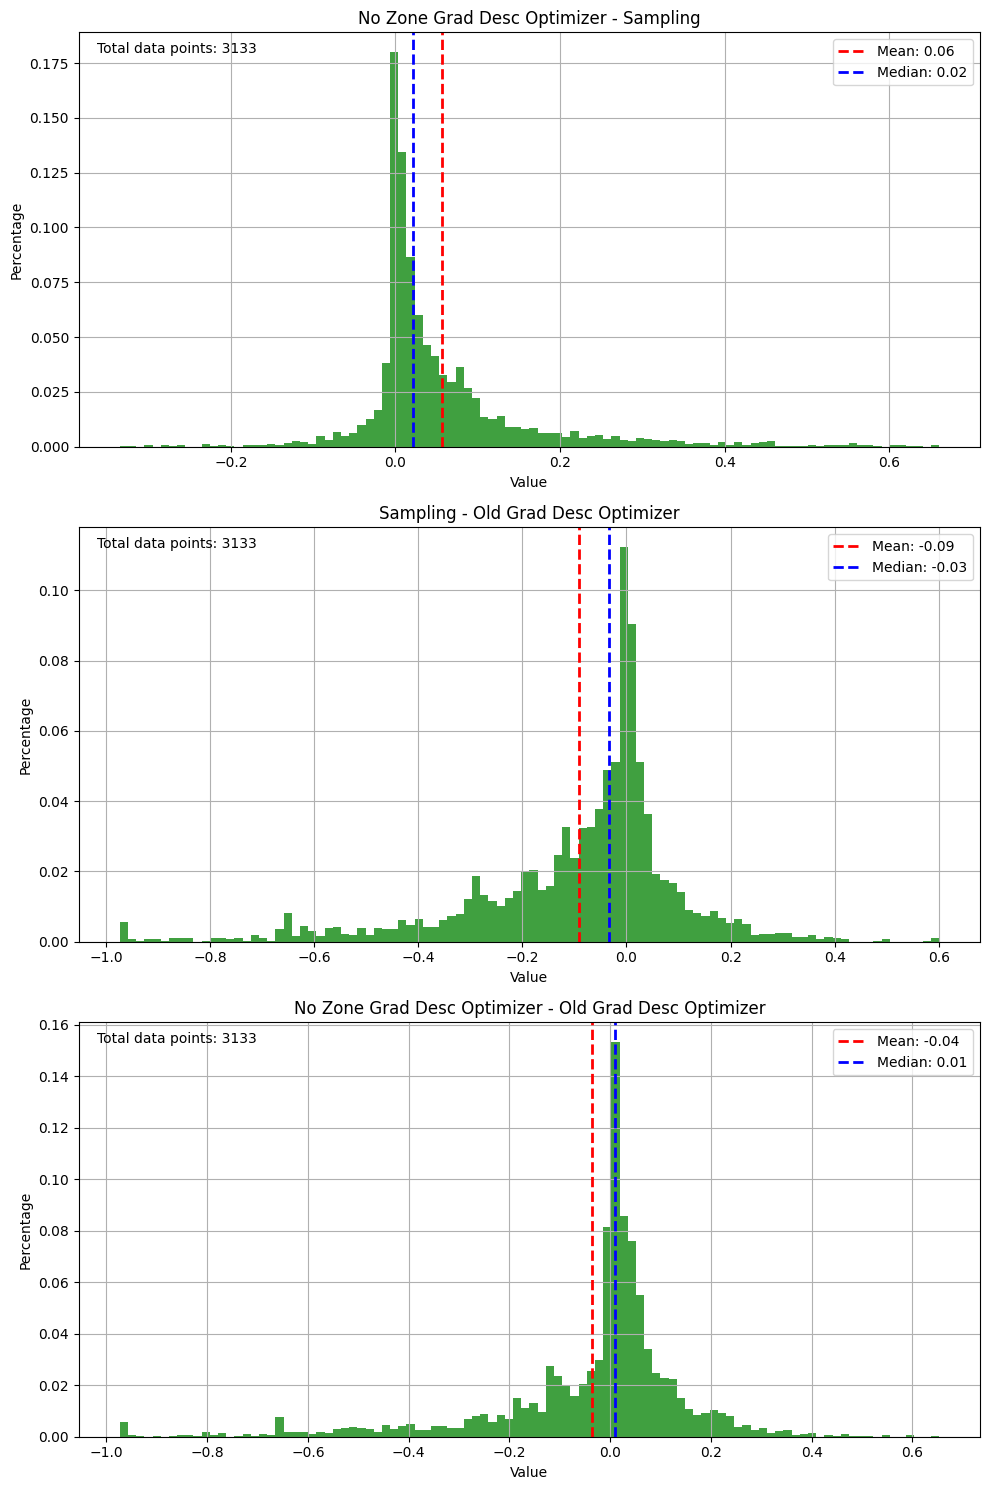

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV files
df_blue = pd.read_csv('pass_gen_comparison_blue.csv', header=None)
df_yellow = pd.read_csv('pass_gen_comparison_yellow.csv', header=None)

# Concatenate the dataframes
df_combined = pd.concat([df_blue, df_yellow], axis=0)
df_combined = df_combined.dropna()

# Create a figure with three subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# Define the pairs of columns to subtract and their titles
pairs = [(0, 1), (1, 2), (0, 2)]
titles = ["No Zone Grad Desc Optimizer", "Sampling", "Old Grad Desc Optimizer"] # ["Column 1 - Column 2", "Column 2 - Column 3", "Column 1 - Column 3"]

# Plot a histogram for each pair of columns
for i, (col1, col2) in enumerate(pairs):
    # Calculate the difference between the columns
    diff = df_combined[col1] - df_combined[col2]

    # Calculate weights for each value to represent percentages
    weights = np.ones_like(diff.values) / len(diff.values)

    # Calculate mean and median
    mean_val = np.mean(diff.values)
    median_val = np.median(diff.values)

    # Calculate total number of data points
    total_data_points = len(diff.values)

    # Plot a histogram
    axs[i].hist(diff.values, bins=100, color='g', alpha=0.75, weights=weights)

    # Draw lines for mean and median
    axs[i].axvline(mean_val, color='r', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axs[i].axvline(median_val, color='b', linestyle='dashed', linewidth=2, label=f'Median: {median_val:.2f}')

    # Add text for total number of data points
    axs[i].text(0.02, 0.95, f'Total data points: {total_data_points}', transform=axs[i].transAxes)

    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Percentage')
    axs[i].set_title(f"{titles[col1]} - {titles[col2]}")
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()